# One-Click Checkout A/B Test Analysis

**Decision question:** Does one-click checkout improve user conversion and revenue without increasing refunds?  
**Unit of randomization and analysis:** user. **Test window:** 28 days. **Alpha:** 0.05 (two-sided).

The notebook is deliberately decision-led: validate the experiment, estimate the primary effect, inspect business value and guardrails, then assess heterogeneity.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.analysis import (bootstrap_mean_difference, conversion_intervals, conversion_test,
                          group_metrics, refund_test, segment_results, srm_test)

sns.set_theme(style='whitegrid', context='talk')
OUTPUTS = ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)
df = pd.read_csv(ROOT / 'data' / 'ab_test_users.csv', parse_dates=['signup_date', 'exposure_date'])
df.head()

,user_id,group,device_type,country,signup_date,exposure_date,session_count,converted,revenue,days_since_signup,refund_rate
0,U000001,control,desktop,US,2025-07-06,2026-04-19,4,False,0.00,287,0
1,U000002,treatment,desktop,US,2024-07-17,2026-04-04,3,False,0.00,626,0
2,U000003,control,desktop,US,2025-12-29,2026-04-07,3,False,0.00,99,0
3,U000004,treatment,mobile,US,2025-11-14,2026-04-10,4,True,60.31,147,0
4,U000005,treatment,tablet,UK,2025-08-21,2026-04-18,2,False,0.00,240,0


## 1. Data quality and randomization checks

We verify uniqueness, missingness, value ranges, assignment balance, and covariate balance before reading outcomes.

In [2]:
quality = {
    'rows': len(df), 'unique_users': df.user_id.nunique(),
    'duplicate_users': int(df.user_id.duplicated().sum()),
    'missing_cells': int(df.isna().sum().sum()),
    'invalid_revenue_rows': int(((df.revenue < 0) | ((~df.converted) & (df.revenue != 0))).sum())
}
quality

{'rows': 50000,
 'unique_users': 50000,
 'duplicate_users': 0,
 'missing_cells': 0,
 'invalid_revenue_rows': 0}

In [3]:
metrics = group_metrics(df)
srm = srm_test(df)
balance = pd.crosstab(df.device_type, df.group, normalize='columns').round(4)
display(metrics, pd.Series(srm, name='SRM check'), balance)

,group,users,conversions,conversion_rate,revenue_per_user
0,control,25000,3550,0.14200,10.706898
1,treatment,25000,3986,0.15944,11.872558


chi_square    0.0
p_value       1.0
Name: SRM check, dtype: float64

group,control,treatment
device_type,,
desktop,0.3402,0.3480
mobile,0.5781,0.5732
tablet,0.0818,0.0788


## 2. Primary metric: conversion

A two-sided two-proportion z-test estimates the intent-to-treat effect. The 95% confidence interval is reported in percentage-point units for decision clarity.

In [4]:
conversion = conversion_test(df)
pd.Series(conversion)

control_rate      1.420000e-01
treatment_rate    1.594400e-01
absolute_lift     1.744000e-02
relative_lift     1.228169e-01
z_statistic       5.449926e+00
p_value           5.039082e-08
ci_low            1.116989e-02
ci_high           2.371011e-02
dtype: float64

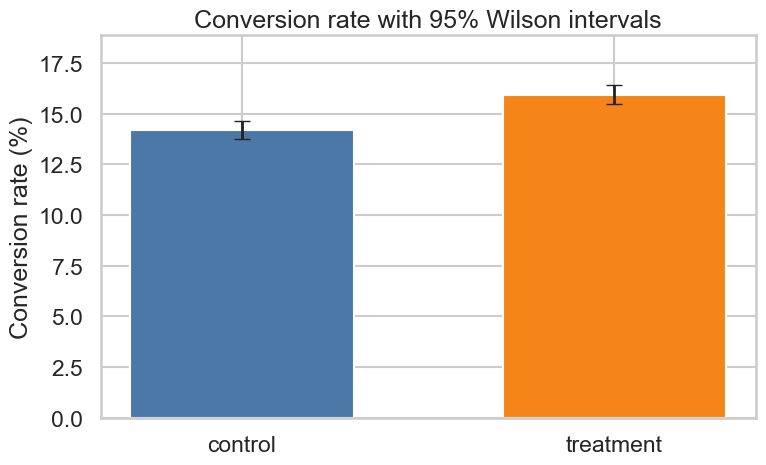

In [5]:
intervals = conversion_intervals(df)
fig, ax = plt.subplots(figsize=(8, 5))
colors = {'control': '#4C78A8', 'treatment': '#F58518'}
ax.bar(intervals.group, intervals.rate * 100, color=[colors[g] for g in intervals.group], width=.6)
ax.errorbar(intervals.group, intervals.rate * 100,
            yerr=[(intervals.rate-intervals.ci_low)*100, (intervals.ci_high-intervals.rate)*100],
            fmt='none', ecolor='#222222', capsize=6, linewidth=2)
ax.set(title='Conversion rate with 95% Wilson intervals', xlabel='', ylabel='Conversion rate (%)')
ax.set_ylim(0, intervals.ci_high.max() * 115)
fig.tight_layout(); fig.savefig(OUTPUTS / 'conversion_by_group.png', dpi=160); plt.show()

## 3. Revenue per user

Revenue per randomized user includes zeros for non-converters. A non-parametric bootstrap is used because revenue is zero-inflated and right-skewed.

In [6]:
revenue = bootstrap_mean_difference(df, 'revenue')
pd.Series(revenue)

control_mean      10.706898
treatment_mean    11.872558
difference         1.165659
ci_low             0.615775
ci_high            1.743353
p_value            0.000400
dtype: float64

## 4. Segment consistency and Simpson's paradox check

Device and country were chosen before analysis. Segment p-values are descriptive and not used as independent shipping gates; signs and assignment mix are checked for reversals.

In [7]:
device = segment_results(df, 'device_type')
country = segment_results(df, 'country')
display(device[['device_type','control_n','treatment_n','control_rate','treatment_rate','absolute_lift','ci_low','ci_high','p_value']],
        country[['country','control_n','treatment_n','control_rate','treatment_rate','absolute_lift','ci_low','ci_high','p_value']])

,device_type,control_n,treatment_n,control_rate,treatment_rate,absolute_lift,ci_low,ci_high,p_value
0,desktop,8504,8701,0.184501,0.197908,0.013407,0.001657,0.025156,0.025389
1,mobile,14452,14330,0.116039,0.134334,0.018294,0.010650,0.025939,0.000003
2,tablet,2044,1969,0.148728,0.172169,0.023441,0.000725,0.046156,0.043001


,country,control_n,treatment_n,control_rate,treatment_rate,absolute_lift,ci_low,ci_high,p_value
0,AU,2263,2243,0.140521,0.159608,0.019086,-0.001764,0.039937,0.072828
1,CA,3568,3487,0.133128,0.150846,0.017718,0.001428,0.034008,0.032974
2,DE,3179,3259,0.109783,0.133783,0.024000,0.008041,0.039960,0.003256
3,UK,4422,4523,0.146766,0.166040,0.019274,0.004228,0.034320,0.012129
4,US,11568,11488,0.152057,0.166696,0.014638,0.005190,0.024086,0.002394


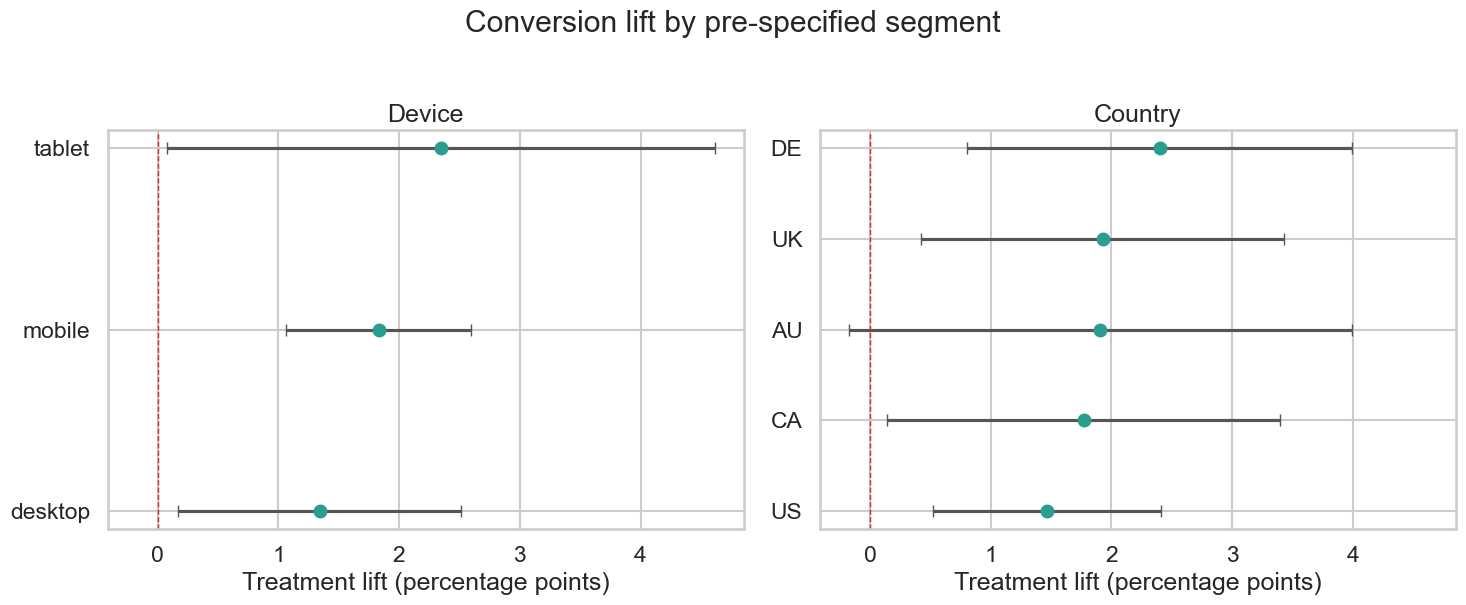

In [8]:
segments = pd.concat([device.assign(segment_type='Device', segment=device.device_type),
                      country.assign(segment_type='Country', segment=country.country)], ignore_index=True)
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True)
for ax, (kind, frame) in zip(axes, segments.groupby('segment_type', sort=False)):
    frame = frame.sort_values('absolute_lift')
    ax.errorbar(frame.absolute_lift * 100, frame.segment,
                xerr=[(frame.absolute_lift-frame.ci_low)*100, (frame.ci_high-frame.absolute_lift)*100],
                fmt='o', color='#2A9D8F', ecolor='#555555', capsize=4)
    ax.axvline(0, color='#D62728', linestyle='--', linewidth=1)
    ax.set(title=kind, xlabel='Treatment lift (percentage points)', ylabel='')
fig.suptitle('Conversion lift by pre-specified segment', y=1.02)
fig.tight_layout(); fig.savefig(OUTPUTS / 'segment_lift.png', dpi=160, bbox_inches='tight'); plt.show()

## 5. Guardrail: refund rate

Refund rate is evaluated among converted users, the population at risk of a refund. The experiment is considered safe when there is no statistically significant increase and the point estimate remains operationally small.

In [9]:
refund = refund_test(df)
pd.Series(refund)

refund_control_rate      0.059718
refund_treatment_rate    0.060963
refund_absolute_lift     0.001245
refund_relative_lift     0.020849
refund_z_statistic       0.226512
refund_p_value           0.820803
refund_ci_low           -0.009522
refund_ci_high           0.012012
dtype: float64

## 6. Decision and export

The shipping rule requires: valid randomization (SRM p >= 0.01), positive significant conversion lift, and no significant refund increase. Revenue is supporting evidence rather than a required gate.

In [10]:
simpsons_reversal = bool((segments.absolute_lift < 0).all() and conversion['absolute_lift'] > 0)
ship = bool(srm['p_value'] >= 0.01 and conversion['p_value'] < 0.05 and conversion['absolute_lift'] > 0
            and not (refund['refund_p_value'] < 0.05 and refund['refund_absolute_lift'] > 0))
decision = 'SHIP' if ship else 'DO NOT SHIP'

metrics.to_csv(OUTPUTS / 'group_metrics.csv', index=False)
device.to_csv(OUTPUTS / 'device_segment_results.csv', index=False)
country.to_csv(OUTPUTS / 'country_segment_results.csv', index=False)
results = {'decision': decision, 'quality': quality, 'srm': srm, 'conversion': conversion,
           'revenue': revenue, 'refund': refund, 'simpsons_reversal': simpsons_reversal}
with open(OUTPUTS / 'analysis_results.json', 'w') as handle: json.dump(results, handle, indent=2)

summary = f'''# Executive Summary: One-Click Checkout Experiment

## Recommendation: {decision}

The 28-day randomized experiment included **{len(df):,} users**. Treatment conversion was **{conversion['treatment_rate']:.2%}** versus **{conversion['control_rate']:.2%}** in control, an absolute lift of **{conversion['absolute_lift']:.2%}** (95% CI **[{conversion['ci_low']:.2%}, {conversion['ci_high']:.2%}]**, p={conversion['p_value']:.4f}). This is a **{conversion['relative_lift']:.1%} relative lift**.

Revenue per user moved from **${revenue['control_mean']:.2f}** to **${revenue['treatment_mean']:.2f}** (difference **${revenue['difference']:.2f}**, bootstrap 95% CI **[${revenue['ci_low']:.2f}, ${revenue['ci_high']:.2f}]**). Refund rate among buyers was **{refund['refund_treatment_rate']:.2%}** versus **{refund['refund_control_rate']:.2%}** (difference **{refund['refund_absolute_lift']:.2%}**, p={refund['refund_p_value']:.3f}), with no statistically significant deterioration.

## Decision Rationale

- Randomization passed the SRM check (p={srm['p_value']:.3f}); device allocation was also directionally balanced.
- The primary conversion effect is positive and statistically significant at alpha=0.05.
- There is **{'no' if not simpsons_reversal else 'a'} Simpson's-paradox sign reversal** across the pre-specified device and country views.
- The refund guardrail did not show a significant increase. Revenue provides {'positive' if revenue['difference'] > 0 else 'negative'} supporting evidence.

## Assumptions and Limitations

- This is synthetic, user-level intent-to-treat data; production logging defects, interference, bots, and repeat-device identity issues are not represented.
- The 28-day window measures near-term behavior only. Monitor refunds, support contacts, latency, and repeat purchase after rollout.
- Segment estimates are exploratory and underpowered; no multiplicity adjustment was applied.
- Revenue is simulated in a common currency and excludes payment fees, tax, and downstream margin.

## Rollout Plan

Use a staged rollout with live guardrail monitoring and an automatic rollback threshold. Recheck conversion, refunds, latency, and customer-support contacts after two full purchase cycles before moving to 100% exposure.
'''
(ROOT / 'docs' / 'executive_summary.md').write_text(summary, encoding='utf-8')
print(decision)
pd.Series(results)

SHIP


decision                                                          SHIP
quality              {'rows': 50000, 'unique_users': 50000, 'duplic...
srm                                {'chi_square': 0.0, 'p_value': 1.0}
conversion           {'control_rate': 0.142, 'treatment_rate': 0.15...
revenue              {'control_mean': 10.706898399999998, 'treatmen...
refund               {'refund_control_rate': 0.05971830985915493, '...
simpsons_reversal                                                False
dtype: object